# Deep Learning Classifier -- Base vs Feature Engineered

Two `TabularNet` models (fully-connected, BatchNorm, Dropout) are trained and compared:

| Model | Input features |
|---|---|
| **Base** | 13 standardised features (same as `decision_tree.ipynb`) |
| **Engineered** | 32 features: 13 base + 9 |abs| + 10 |A|x|B| pairwise products |

Both models use:
- `BCEWithLogitsLoss` with `pos_weight` to counteract the ~7.4 % minority class
- `AdamW` optimiser with L2 weight decay
- `ReduceLROnPlateau` LR schedule (halves after 5 stale epochs, tracks val F1)
- Early stopping on **validation F1** (patience = 10 epochs)
- Final metrics reported on the held-out **test set** with threshold tuning

> **GPU note**: this notebook detects CUDA automatically.
> The current install is CPU-only (`torch==2.11.0+cpu`).
> To enable GPU training reinstall PyTorch for your CUDA version:
> `pip install torch --index-url https://download.pytorch.org/whl/cu121`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, precision_recall_curve,
)

# -- Device ------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM : {mem:.1f} GB')
else:
    print('  WARNING: CUDA not available -- running on CPU')
    print('  Install CUDA PyTorch: pip install torch --index-url https://download.pytorch.org/whl/cu121')

# -- Data --------------------------------------------------------------------
path   = '../Data/SyntheticData/2026_03_31_01_52_14/std_synthetic_data_2026_03_31_01_52_14.csv'
df     = pd.read_csv(path)
target = 'Problem_SKU'
seed   = 1337

numeric_features = [
    'Global_SKU_Defect_Rate_%_std',
    'ABS_Volume_Difference_std',
    'Aisle_Hold_%_std',
    '#_Pick_Events_std',
    '#_Pick_Events_In_Clique_std',
    '#_Picks_std',
    '#_Picks_In_Clique_std',
    'Time_In_Loc_std',
    'Current_Max_Volume_std',
]
size_dummies  = pd.get_dummies(df['Storage_Size'], prefix='Size', drop_first=True).astype(int)
defect_linked = df['Defect_In_Linked_Receive'].astype(int)

X_base = pd.concat([df[numeric_features], size_dummies, defect_linked], axis=1)
y      = df[target].astype(int)

# 80/20 train-test (same seed as all other notebooks)
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=seed, stratify=y
)
# Sub-split train -> 80% fit / 20% val for early stopping
X_tr_base, X_val_base, y_tr, y_val = train_test_split(
    X_train_base, y_train, test_size=0.2, random_state=seed, stratify=y_train
)

pos_weight_val = float((y_tr == 0).sum()) / float((y_tr == 1).sum())
print(f'\nFit   : {X_tr_base.shape}')
print(f'Val   : {X_val_base.shape}')
print(f'Test  : {X_test_base.shape}')
print(f'Positive rate (fit) : {y_tr.mean():.3f}')
print(f'pos_weight          : {pos_weight_val:.2f}  (negatives / positives)')

Device : cpu
  Install CUDA PyTorch: pip install torch --index-url https://download.pytorch.org/whl/cu121

Fit   : (176000, 13)
Val   : (44000, 13)
Test  : (55000, 13)
Positive rate (fit) : 0.074
pos_weight          : 12.58  (negatives / positives)


In [2]:
# -- Feature engineering (mirrors decision_tree_feature_engineered.ipynb) ---
top5 = [
    '#_Picks_In_Clique_std',
    'Aisle_Hold_%_std',
    'Current_Max_Volume_std',
    '#_Picks_std',
    'ABS_Volume_Difference_std',
]
short = {
    '#_Picks_In_Clique_std':     'picks_clique',
    'Aisle_Hold_%_std':          'aisle',
    'Current_Max_Volume_std':    'max_vol',
    '#_Picks_std':               'picks',
    'ABS_Volume_Difference_std': 'abs_vol',
}

def engineer_features(X):
    Xe = X.copy()
    # |z| captures extremeness regardless of direction
    for col in numeric_features:
        Xe[f'|{col}|'] = X[col].abs()
    # |A|x|B|: products of absolute values avoid sign ambiguity on z-scores
    for f1, f2 in combinations(top5, 2):
        Xe[f'|{short[f1]}| x |{short[f2]}|'] = X[f1].abs() * X[f2].abs()
    return Xe

X_tr_eng   = engineer_features(X_tr_base)
X_val_eng  = engineer_features(X_val_base)
X_test_eng = engineer_features(X_test_base)

n_base = X_tr_base.shape[1]
n_eng  = X_tr_eng.shape[1]
print(f'Base features       : {n_base}')
print(f'Engineered features : {n_eng}  (+{n_eng - n_base} engineered)')

Base features       : 13
Engineered features : 32  (+19 engineered)


## Model Architecture & Training Infrastructure

```
Input (n_features)
  Linear(n, 256) -> BatchNorm1d -> ReLU -> Dropout(0.3)
  Linear(256,128) -> BatchNorm1d -> ReLU -> Dropout(0.3)
  Linear(128, 64) -> BatchNorm1d -> ReLU -> Dropout(0.3)
  Linear(64, 1)   -> logit output
```

- **Loss**: `BCEWithLogitsLoss(pos_weight=neg/pos ~12.5)` -- numerically stable, handles imbalance
- **Optimiser**: `AdamW(lr=1e-3, weight_decay=1e-4)`
- **Schedule**: `ReduceLROnPlateau(mode='max', factor=0.5, patience=5)` tracks val F1
- **Early stop**: patience=10 epochs on val F1; restores best checkpoint
- **Batch size**: 1024 (fits comfortably in GPU VRAM; also fine on CPU)

In [3]:
def make_loaders(X_tr, y_tr, X_val, y_val, batch_size=1024):
    # Convert DataFrames to TensorDatasets and wrap in DataLoaders
    def to_ds(X, y):
        return TensorDataset(
            torch.tensor(X.values, dtype=torch.float32),
            torch.tensor(y.values, dtype=torch.float32),
        )
    pin = device.type == 'cuda'
    return (
        DataLoader(to_ds(X_tr,  y_tr),  batch_size=batch_size,    shuffle=True,
                   num_workers=0, pin_memory=pin),
        DataLoader(to_ds(X_val, y_val), batch_size=batch_size * 4, shuffle=False,
                   num_workers=0, pin_memory=pin),
    )


class TabularNet(nn.Module):
    # Feed-forward network for tabular binary classification.
    # Each hidden block: Linear -> BatchNorm1d -> ReLU -> Dropout.
    # Output: single raw logit -- pair with BCEWithLogitsLoss.
    def __init__(self, n_in, hidden=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, dim = [], n_in
        for h in hidden:
            layers += [
                nn.Linear(dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            dim = h
        layers.append(nn.Linear(dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)   # shape: (batch,)


# Sanity-check forward pass
_net = TabularNet(n_base)
assert _net(torch.zeros(4, n_base)).shape == (4,), 'forward pass shape mismatch'
n_params_base = sum(p.numel() for p in TabularNet(n_base).parameters())
n_params_eng  = sum(p.numel() for p in TabularNet(n_eng).parameters())
print('TabularNet forward pass : OK')
print(f'  Base  input={n_base:2d}  params: {n_params_base:,}')
print(f'  Eng   input={n_eng:2d}  params: {n_params_eng:,}')

TabularNet forward pass : OK
  Base  input=13  params: 45,697
  Eng   input=32  params: 50,561


In [4]:
def train_model(model, train_loader, val_loader,
                pos_weight, n_epochs=100, lr=1e-3,
                patience=10, label='model'):
    # BCEWithLogitsLoss + AdamW + ReduceLROnPlateau.
    # Saves best checkpoint by val F1; restores it on early stop or completion.
    # Returns history dict with per-epoch metrics.
    pw        = torch.tensor([pos_weight], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    hist = {'train_loss': [], 'val_loss': [],
            'val_f1': [], 'val_precision': [], 'val_recall': []}
    best_f1, best_state, no_improve = 0.0, None, 0

    for epoch in range(n_epochs):
        # -- Train -----------------------------------------------------------
        model.train()
        run = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            run += loss.item() * len(yb)
        train_loss = run / len(train_loader.dataset)

        # -- Validate --------------------------------------------------------
        model.eval()
        run, probas, labels = 0.0, [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                logits = model(Xb)
                run += criterion(logits, yb).item() * len(yb)
                probas.extend(torch.sigmoid(logits).cpu().numpy())
                labels.extend(yb.cpu().numpy())
        val_loss = run / len(val_loader.dataset)
        probas   = np.array(probas)
        labels   = np.array(labels, dtype=int)

        # Threshold sweep on val -> best F1
        val_f1, val_p, val_r, best_t = 0.0, 0.0, 0.0, 0.5
        for t in np.arange(0.05, 0.95, 0.01):
            preds = (probas >= t).astype(int)
            if preds.sum() == 0:
                continue
            f = f1_score(labels, preds, zero_division=0)
            if f > val_f1:
                val_f1 = f
                val_p  = precision_score(labels, preds, zero_division=0)
                val_r  = recall_score(labels, preds, zero_division=0)
                best_t = t

        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
        hist['val_f1'].append(val_f1)
        hist['val_precision'].append(val_p)
        hist['val_recall'].append(val_r)

        scheduler.step(val_f1)
        lr_now = optimizer.param_groups[0]['lr']

        improved = val_f1 > best_f1
        if improved:
            best_f1    = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        # Print every 5 epochs or on improvement
        if (epoch + 1) % 5 == 0 or improved:
            flag = ' *' if improved else ''
            print(f'[{label}] ep {epoch+1:3d}  '
                  f'tr={train_loss:.4f}  val={val_loss:.4f}  '
                  f'F1={val_f1:.4f}  P={val_p:.3f}  R={val_r:.3f}  '
                  f't={best_t:.2f}  lr={lr_now:.1e}{flag}')

        if no_improve >= patience:
            print(f'  -> early stop at epoch {epoch + 1}  '
                  f'(best val F1 = {best_f1:.4f})')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return hist

## Training

Both models use identical hyperparameters; the only variable is the feature set.
A `*` in the training log marks epochs where val F1 improved.

In [5]:
torch.manual_seed(seed)
model_base = TabularNet(n_in=n_base, hidden=(256, 128, 64), dropout=0.3).to(device)
print(f'Base model  --  input dim: {n_base}  '
      f'params: {sum(p.numel() for p in model_base.parameters()):,}')
print()

train_loader_base, val_loader_base = make_loaders(X_tr_base, y_tr, X_val_base, y_val)
hist_base = train_model(
    model_base, train_loader_base, val_loader_base,
    pos_weight=pos_weight_val, n_epochs=100, lr=1e-3, patience=10, label='base'
)

Base model  --  input dim: 13  params: 45,697

[base] ep   1  tr=0.9171  val=0.8560  F1=0.4690  P=0.472  R=0.466  t=0.79  lr=1.0e-03 *
[base] ep   2  tr=0.8745  val=0.8492  F1=0.4694  P=0.439  R=0.504  t=0.77  lr=1.0e-03 *
[base] ep   3  tr=0.8676  val=0.8462  F1=0.4753  P=0.494  R=0.458  t=0.80  lr=1.0e-03 *
[base] ep   5  tr=0.8602  val=0.8409  F1=0.4785  P=0.461  R=0.497  t=0.78  lr=1.0e-03 *
[base] ep   7  tr=0.8537  val=0.8400  F1=0.4827  P=0.472  R=0.494  t=0.77  lr=1.0e-03 *
[base] ep   8  tr=0.8498  val=0.8376  F1=0.4848  P=0.489  R=0.481  t=0.80  lr=1.0e-03 *
[base] ep  10  tr=0.8448  val=0.8348  F1=0.4831  P=0.470  R=0.497  t=0.79  lr=1.0e-03
[base] ep  15  tr=0.8385  val=0.8329  F1=0.4843  P=0.458  R=0.514  t=0.79  lr=5.0e-04
[base] ep  18  tr=0.8355  val=0.8324  F1=0.4852  P=0.482  R=0.488  t=0.81  lr=5.0e-04 *
[base] ep  19  tr=0.8375  val=0.8322  F1=0.4855  P=0.487  R=0.484  t=0.81  lr=5.0e-04 *
[base] ep  20  tr=0.8353  val=0.8328  F1=0.4853  P=0.493  R=0.478  t=0.81  lr

In [6]:
torch.manual_seed(seed)
model_eng = TabularNet(n_in=n_eng, hidden=(256, 128, 64), dropout=0.3).to(device)
print(f'Eng model   --  input dim: {n_eng}  '
      f'params: {sum(p.numel() for p in model_eng.parameters()):,}')
print()

train_loader_eng, val_loader_eng = make_loaders(X_tr_eng, y_tr, X_val_eng, y_val)
hist_eng = train_model(
    model_eng, train_loader_eng, val_loader_eng,
    pos_weight=pos_weight_val, n_epochs=100, lr=1e-3, patience=10, label='eng'
)

Eng model   --  input dim: 32  params: 50,561

[eng] ep   1  tr=0.9072  val=0.8463  F1=0.4780  P=0.453  R=0.506  t=0.79  lr=1.0e-03 *
[eng] ep   2  tr=0.8579  val=0.8400  F1=0.4804  P=0.479  R=0.481  t=0.79  lr=1.0e-03 *
[eng] ep   3  tr=0.8511  val=0.8378  F1=0.4817  P=0.478  R=0.485  t=0.81  lr=1.0e-03 *
[eng] ep   4  tr=0.8467  val=0.8381  F1=0.4825  P=0.471  R=0.494  t=0.82  lr=1.0e-03 *
[eng] ep   5  tr=0.8441  val=0.8391  F1=0.4843  P=0.473  R=0.497  t=0.78  lr=1.0e-03 *
[eng] ep   9  tr=0.8354  val=0.8359  F1=0.4856  P=0.489  R=0.482  t=0.80  lr=1.0e-03 *
[eng] ep  10  tr=0.8329  val=0.8345  F1=0.4861  P=0.492  R=0.481  t=0.80  lr=1.0e-03 *
[eng] ep  11  tr=0.8352  val=0.8336  F1=0.4886  P=0.502  R=0.476  t=0.81  lr=1.0e-03 *
[eng] ep  15  tr=0.8296  val=0.8370  F1=0.4863  P=0.496  R=0.477  t=0.81  lr=1.0e-03
[eng] ep  20  tr=0.8223  val=0.8352  F1=0.4882  P=0.478  R=0.498  t=0.79  lr=5.0e-04
  -> early stop at epoch 21  (best val F1 = 0.4886)


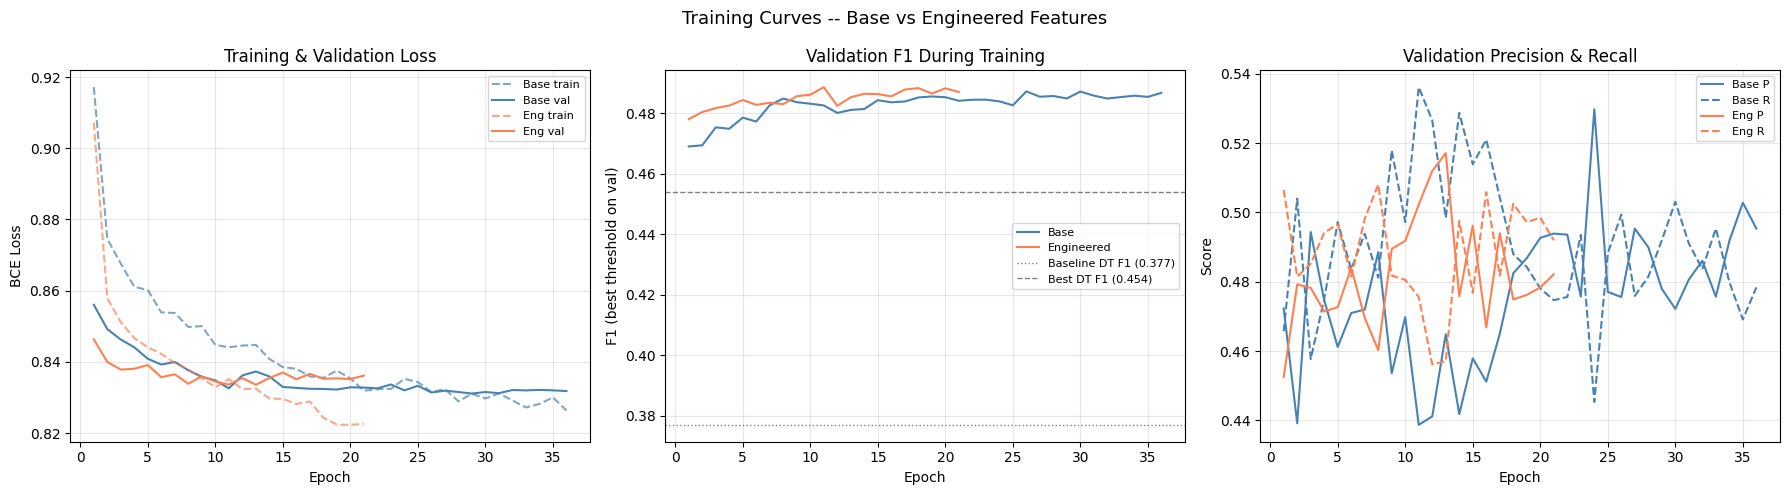

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ep_b = range(1, len(hist_base['train_loss']) + 1)
ep_e = range(1, len(hist_eng['train_loss'])  + 1)

# Loss
ax = axes[0]
ax.plot(ep_b, hist_base['train_loss'], color='steelblue', linestyle='--', alpha=0.7, label='Base train')
ax.plot(ep_b, hist_base['val_loss'],   color='steelblue',                 label='Base val')
ax.plot(ep_e, hist_eng['train_loss'],  color='coral',     linestyle='--', alpha=0.7, label='Eng train')
ax.plot(ep_e, hist_eng['val_loss'],    color='coral',                     label='Eng val')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('Training & Validation Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Val F1
ax2 = axes[1]
ax2.plot(ep_b, hist_base['val_f1'], color='steelblue', label='Base')
ax2.plot(ep_e, hist_eng['val_f1'],  color='coral',     label='Engineered')
ax2.axhline(0.377, color='gray', linestyle=':',  linewidth=1, label='Baseline DT F1 (0.377)')
ax2.axhline(0.454, color='gray', linestyle='--', linewidth=1, label='Best DT F1 (0.454)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1 (best threshold on val)')
ax2.set_title('Validation F1 During Training')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Val Precision & Recall
ax3 = axes[2]
ax3.plot(ep_b, hist_base['val_precision'], color='steelblue',                 label='Base P')
ax3.plot(ep_b, hist_base['val_recall'],    color='steelblue', linestyle='--', label='Base R')
ax3.plot(ep_e, hist_eng['val_precision'],  color='coral',                     label='Eng P')
ax3.plot(ep_e, hist_eng['val_recall'],     color='coral',     linestyle='--', label='Eng R')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Score')
ax3.set_title('Validation Precision & Recall')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

plt.suptitle('Training Curves -- Base vs Engineered Features', fontsize=13)
plt.tight_layout(); plt.show()

## Test-Set Evaluation

For each model:
1. Predict probabilities on the held-out test set (never seen during training or early stopping)
2. Report metrics at **default threshold 0.50**
3. Sweep thresholds 0.05-0.95 and report at the **F1-maximising threshold**

In [8]:
def eval_on_test(model, X_test_df, y_test_series, label):
    model.eval()
    Xt = torch.tensor(X_test_df.values, dtype=torch.float32, device=device)
    with torch.no_grad():
        proba = torch.sigmoid(model(Xt)).cpu().numpy()

    y_ts = y_test_series.values

    # Threshold sweep -> best F1
    best_f1, best_t, best_p, best_r = 0.0, 0.5, 0.0, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        preds = (proba >= t).astype(int)
        if preds.sum() == 0:
            continue
        f = f1_score(y_ts, preds, zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_t  = t
            best_p  = precision_score(y_ts, preds, zero_division=0)
            best_r  = recall_score(y_ts, preds, zero_division=0)

    auc   = roc_auc_score(y_ts, proba)
    ap    = average_precision_score(y_ts, proba)
    f1_50 = f1_score(y_ts, (proba >= 0.5).astype(int), zero_division=0)
    p_50  = precision_score(y_ts, (proba >= 0.5).astype(int), zero_division=0)
    r_50  = recall_score(y_ts, (proba >= 0.5).astype(int), zero_division=0)

    sep = '-' * 58
    print(f'\n{sep}\n  {label}\n{sep}')
    print(f'\n  Default threshold (0.50):')
    print(classification_report(y_ts, (proba >= 0.5).astype(int), digits=3))
    print(f'  F1-optimal threshold ({best_t:.2f}):')
    print(classification_report(y_ts, (proba >= best_t).astype(int), digits=3))
    print(f'  ROC-AUC : {auc:.4f}   Avg Precision : {ap:.4f}')

    return dict(label=label, proba=proba,
                f1_50=f1_50, p_50=p_50, r_50=r_50,
                f1_opt=best_f1, p_opt=best_p, r_opt=best_r,
                threshold=best_t, auc=auc, ap=ap)


res_base = eval_on_test(model_base, X_test_base, y_test, 'Base DL (13 features)')
res_eng  = eval_on_test(model_eng,  X_test_eng,  y_test, 'Engineered DL (32 features)')


----------------------------------------------------------
  Base DL (13 features)
----------------------------------------------------------

  Default threshold (0.50):
              precision    recall  f1-score   support

           0      0.978     0.813     0.888     50951
           1      0.247     0.769     0.373      4049

    accuracy                          0.810     55000
   macro avg      0.612     0.791     0.631     55000
weighted avg      0.924     0.810     0.850     55000

  F1-optimal threshold (0.80):
              precision    recall  f1-score   support

           0      0.960     0.956     0.958     50951
           1      0.474     0.499     0.486      4049

    accuracy                          0.922     55000
   macro avg      0.717     0.728     0.722     55000
weighted avg      0.924     0.922     0.923     55000

  ROC-AUC : 0.8695   Avg Precision : 0.4869

----------------------------------------------------------
  Engineered DL (32 features)
---------

                               Model    F1  Precision  Recall   AUC    AP
     Baseline DT (no weight, t=0.50) 0.377      0.621   0.270 0.814   NaN
             Best DT F1-opt (t=0.50) 0.454      0.433   0.477 0.848   NaN
       Base DL (13 features)  t=0.50 0.373      0.247   0.769 0.869 0.487
Engineered DL (32 features)   t=0.50 0.368      0.241   0.776 0.870 0.491
       Base DL (13 features)  t=0.80 0.486      0.474   0.499 0.869 0.487
Engineered DL (32 features)   t=0.78 0.486      0.463   0.511 0.870 0.491


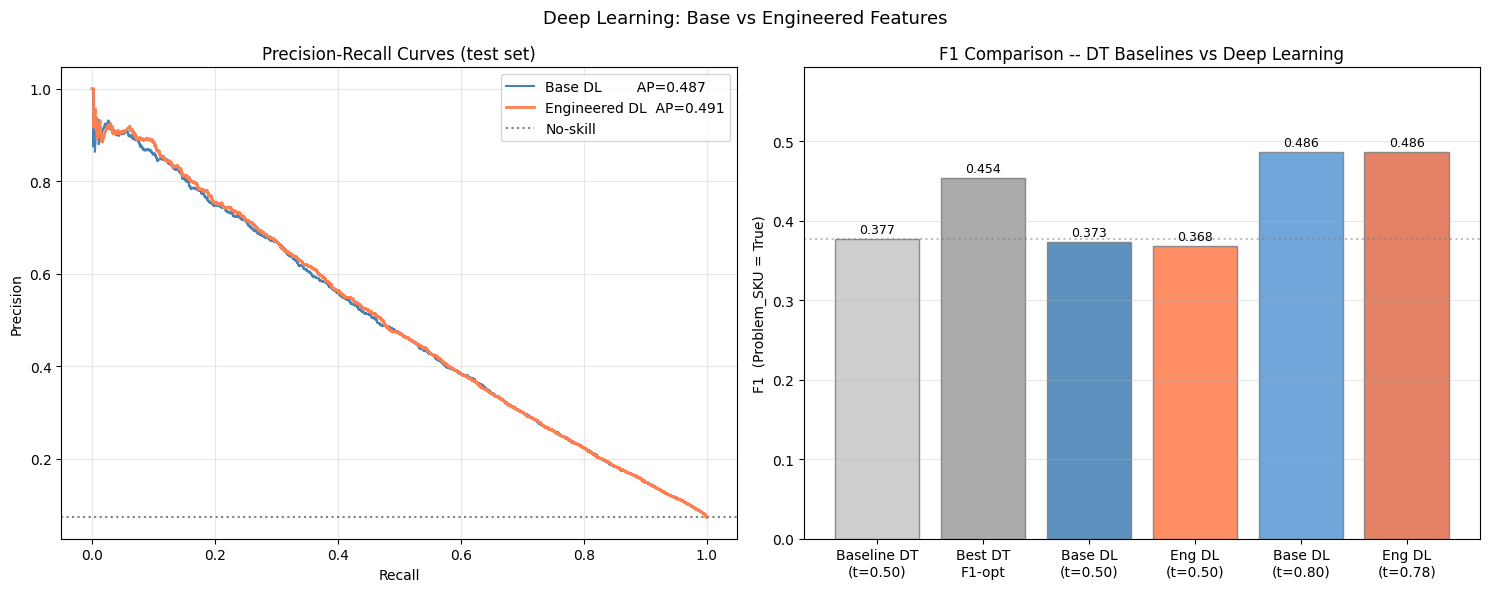

In [9]:
# -- Summary table -----------------------------------------------------------
rows = [
    {'Model': 'Baseline DT (no weight, t=0.50)', 'F1': 0.377, 'Precision': 0.621, 'Recall': 0.270, 'AUC': 0.814, 'AP': None},
    {'Model': 'Best DT F1-opt (t=0.50)',          'F1': 0.454, 'Precision': 0.433, 'Recall': 0.477, 'AUC': 0.848, 'AP': None},
    {'Model': f"{res_base['label']}  t=0.50",    'F1': res_base['f1_50'],  'Precision': res_base['p_50'],  'Recall': res_base['r_50'],  'AUC': res_base['auc'], 'AP': res_base['ap']},
    {'Model': f"{res_eng['label']}   t=0.50",    'F1': res_eng['f1_50'],   'Precision': res_eng['p_50'],   'Recall': res_eng['r_50'],   'AUC': res_eng['auc'],  'AP': res_eng['ap']},
    {'Model': f"{res_base['label']}  t={res_base['threshold']:.2f}", 'F1': res_base['f1_opt'], 'Precision': res_base['p_opt'], 'Recall': res_base['r_opt'], 'AUC': res_base['auc'], 'AP': res_base['ap']},
    {'Model': f"{res_eng['label']}   t={res_eng['threshold']:.2f}",  'F1': res_eng['f1_opt'],  'Precision': res_eng['p_opt'],  'Recall': res_eng['r_opt'],  'AUC': res_eng['auc'],  'AP': res_eng['ap']},
]
comp = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.3f}'.format)
print(comp.to_string(index=False))

# -- Plots -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PR curves
ax = axes[0]
p, r, _ = precision_recall_curve(y_test, res_base['proba'])
ax.plot(r, p, color='steelblue', linewidth=1.5,
        label=f"Base DL        AP={res_base['ap']:.3f}")
p, r, _ = precision_recall_curve(y_test, res_eng['proba'])
ax.plot(r, p, color='coral', linewidth=2,
        label=f"Engineered DL  AP={res_eng['ap']:.3f}")
ax.axhline(y_test.mean(), color='gray', linestyle=':', label='No-skill')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (test set)')
ax.legend(); ax.grid(alpha=0.3)

# F1 bar chart
ax2 = axes[1]
model_labels = [
    'Baseline DT\n(t=0.50)',
    'Best DT\nF1-opt',
    'Base DL\n(t=0.50)',
    'Eng DL\n(t=0.50)',
    f"Base DL\n(t={res_base['threshold']:.2f})",
    f"Eng DL\n(t={res_eng['threshold']:.2f})",
]
f1_vals = [0.377, 0.454,
           res_base['f1_50'], res_eng['f1_50'],
           res_base['f1_opt'], res_eng['f1_opt']]
bar_colors = ['#c8c8c8', '#a0a0a0',
              'steelblue', 'coral', '#5b9bd5', '#e07050']
bars = ax2.bar(model_labels, f1_vals, color=bar_colors, alpha=0.88, edgecolor='gray')
for bar, val in zip(bars, f1_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.004,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax2.axhline(0.377, color='gray', linestyle=':', alpha=0.5)
ax2.set_ylim(0, max(f1_vals) * 1.22)
ax2.set_ylabel('F1  (Problem_SKU = True)')
ax2.set_title('F1 Comparison -- DT Baselines vs Deep Learning')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Deep Learning: Base vs Engineered Features', fontsize=13)
plt.tight_layout(); plt.show()